In [3]:
from google.colab import files
import pandas as pd
import ast
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack

# Upload files
uploaded = files.upload()


Saving disease_features.csv to disease_features.csv
Saving encoded_output2.csv to encoded_output2.csv


In [4]:
# Now load the uploaded CSVs
df = pd.read_csv('disease_features.csv')
one_hot_df = pd.read_csv('encoded_output2.csv')

df.head()


,Disease,Risk Factors,Symptoms,Signs,Subtypes
0,Acute Coronary Syndrome,"['Hyperlipidemia', 'hypertension', 'smoking', ...","['Chest pain', 'sweating', 'nausea', 'vomiting...",[],"{'UA': 'hs-cTn levels are normal，Normal ECG', ..."
1,Adrenal Insufficiency,"['Autoimmune diseases', 'Genetic predispositio...","['Fatigue', 'Muscle weakness', 'Weight loss', ...",['Hyperpigmentation (especially in creases of ...,"{'Primary Adrenal Insufficiency': ""1. Often th..."
2,Alzheimer,"['Age', 'genetic factors', 'gender', 'cardiova...","['Cognitive decline, including memory loss and...",[],"{'Alzheimer': ""1. Clinical Assessment\n Det..."
3,Aortic Dissection,"['Hypertension', 'Atherosclerosis', 'Family hi...","['Intense chest or upper back pain', 'Sudden s...",[],"{'Type A Aortic Dissection': 'CT, MRI, TEE che..."
4,Asthma,"['Allergies', 'family history of asthma or all...","['Recurrent episodes of wheezing', 'breathless...",['Observable signs during a physical examinati...,"{'Severe Asthma': ""doesn't respond well to con..."


In [7]:
for col in ['Risk Factors', 'Symptoms', 'Signs']:
    df[col] = df[col].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

df[['Risk Factors', 'Symptoms', 'Signs']].head()


,Risk Factors,Symptoms,Signs
0,"[Hyperlipidemia, hypertension, smoking, diabet...","[Chest pain, sweating, nausea, vomiting, palpi...",[]
1,"[Autoimmune diseases, Genetic predisposition, ...","[Fatigue, Muscle weakness, Weight loss, Gastro...",[Hyperpigmentation (especially in creases of s...
2,"[Age, genetic factors, gender, cardiovascular ...","[Cognitive decline, including memory loss and ...",[]
3,"[Hypertension, Atherosclerosis, Family history...","[Intense chest or upper back pain, Sudden seve...",[]
4,"[Allergies, family history of asthma or allerg...","[Recurrent episodes of wheezing, breathlessnes...",[Observable signs during a physical examinatio...


In [8]:
# Join list elements into a single space-separated string
for col in ['Risk Factors', 'Symptoms', 'Signs']:
    df[col + '_str'] = df[col].apply(lambda x: ' '.join(x))

df[['Risk Factors_str', 'Symptoms_str', 'Signs_str']].head()


,Risk Factors_str,Symptoms_str,Signs_str
0,Hyperlipidemia hypertension smoking diabetes i...,Chest pain sweating nausea vomiting palpitatio...,
1,Autoimmune diseases Genetic predisposition Inf...,Fatigue Muscle weakness Weight loss Gastrointe...,Hyperpigmentation (especially in creases of sk...
2,Age genetic factors gender cardiovascular heal...,"Cognitive decline, including memory loss and d...",
3,Hypertension Atherosclerosis Family history Hi...,Intense chest or upper back pain Sudden severe...,
4,Allergies family history of asthma or allergie...,Recurrent episodes of wheezing breathlessness ...,Observable signs during a physical examination...


In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize vectorizers
tfidf_risk = TfidfVectorizer()
tfidf_symptoms = TfidfVectorizer()
tfidf_signs = TfidfVectorizer()

# Fit and transform
X_risk = tfidf_risk.fit_transform(df['Risk Factors_str'])
X_symptoms = tfidf_symptoms.fit_transform(df['Symptoms_str'])
X_signs = tfidf_signs.fit_transform(df['Signs_str'])

# Show dimensions
X_risk.shape, X_symptoms.shape, X_signs.shape


((25, 360), (25, 424), (25, 236))

In [10]:
from scipy.sparse import hstack

# Combine all TF-IDF matrices into a single feature matrix
X_tfidf_combined = hstack([X_risk, X_symptoms, X_signs])
X_tfidf_combined.shape


(25, 1020)

In [11]:
# Calculate sparsity
tfidf_sparsity = 1.0 - (X_tfidf_combined.nnz / (X_tfidf_combined.shape[0] * X_tfidf_combined.shape[1]))
onehot_array = one_hot_df.to_numpy()
onehot_sparsity = 1.0 - (np.count_nonzero(onehot_array) / onehot_array.size)

# Unique feature counts
tfidf_features = X_tfidf_combined.shape[1]
onehot_features = one_hot_df.shape[1]

# Display results
print(f"TF-IDF Sparsity: {tfidf_sparsity:.4f}")
print(f"One-Hot Sparsity: {onehot_sparsity:.4f}")
print(f"TF-IDF Feature Count: {tfidf_features}")
print(f"One-Hot Feature Count: {onehot_features}")


TF-IDF Sparsity: 0.9296
One-Hot Sparsity: 0.9515
TF-IDF Feature Count: 1020
One-Hot Feature Count: 497


In [12]:
from sklearn.decomposition import PCA, TruncatedSVD
import matplotlib.pyplot as plt
import seaborn as sns

# Optional: enable inline plotting
%matplotlib inline


In [14]:
one_hot_df.dtypes


,0
Disease,object
Risk_(Nonsteroidal antiinflammatory drugs) NSAIDs Usage,int64
Risk_: Close contact with someone with infectious TB、HIV infection,int64
Risk_Adrenal hemorrhage,int64
Risk_Age,int64
...,...
Subtype_Asthma,int64
Subtype_Migraine With Aura,int64
Subtype_Persistent Atrial Fibrillation,int64
Subtype_Type I Diabetes,int64


In [15]:
# Remove non-numeric columns (e.g., 'Disease' or 'Label')
onehot_numeric = one_hot_df.select_dtypes(include=['number'])

# Now convert to dense numpy array
X_onehot_dense = onehot_numeric.to_numpy()


In [16]:
# PCA and SVD
X_pca_onehot = pca_onehot.fit_transform(X_onehot_dense)
X_svd_onehot = svd_onehot.fit_transform(X_onehot_dense)


In [17]:
def plot_2d(data, title, categories=None):
    plt.figure(figsize=(8, 6))
    if categories is not None:
        sns.scatterplot(x=data[:, 0], y=data[:, 1], hue=categories, palette='Set2', s=60, edgecolor='k')
    else:
        plt.scatter(data[:, 0], data[:, 1], s=50, edgecolors='k')
    plt.title(title)
    plt.xlabel("Component 1")
    plt.ylabel("Component 2")
    plt.grid(True)
    plt.show()


In [18]:
df.columns
one_hot_df.columns


Index(['Disease', 'Risk_(Nonsteroidal antiinflammatory drugs) NSAIDs Usage',
       'Risk_: Close contact with someone with infectious TB、HIV infection',
       'Risk_Adrenal hemorrhage', 'Risk_Age', 'Risk_Age (30s-40s)',
       'Risk_Age and gender', 'Risk_Alcohol', 'Risk_Alcohol and toxins',
       'Risk_Allergies',
       ...
       'Subtype_Pneumonia', 'Subtype_Paroxysmal Atrial Fibrillation',
       'Subtype_HFrEF', 'Subtype_Strongly Suspected ACS',
       'Subtype_Chronic Non-atrophic Gastritis', 'Subtype_Asthma',
       'Subtype_Migraine With Aura', 'Subtype_Persistent Atrial Fibrillation',
       'Subtype_Type I Diabetes', 'Subtype_HFmrEF'],
      dtype='object', length=497)

In [19]:
# Option 1: Use labels from one_hot_df (if present)
labels = one_hot_df['Disease'] if 'Disease' in one_hot_df.columns else None

# Option 2: Use from df (if needed)
# labels = df['Disease'] if 'Disease' in df.columns else None


In [21]:
from sklearn.decomposition import PCA, TruncatedSVD

# Re-initialize objects
pca_tfidf = PCA(n_components=3)
pca_onehot = PCA(n_components=3)
svd_tfidf = TruncatedSVD(n_components=3)
svd_onehot = TruncatedSVD(n_components=3)

# Fit-transform all matrices
X_pca_tfidf = pca_tfidf.fit_transform(X_tfidf_combined.toarray())
X_pca_onehot = pca_onehot.fit_transform(onehot_numeric.to_numpy())
X_svd_tfidf = svd_tfidf.fit_transform(X_tfidf_combined)
X_svd_onehot = svd_onehot.fit_transform(onehot_numeric)


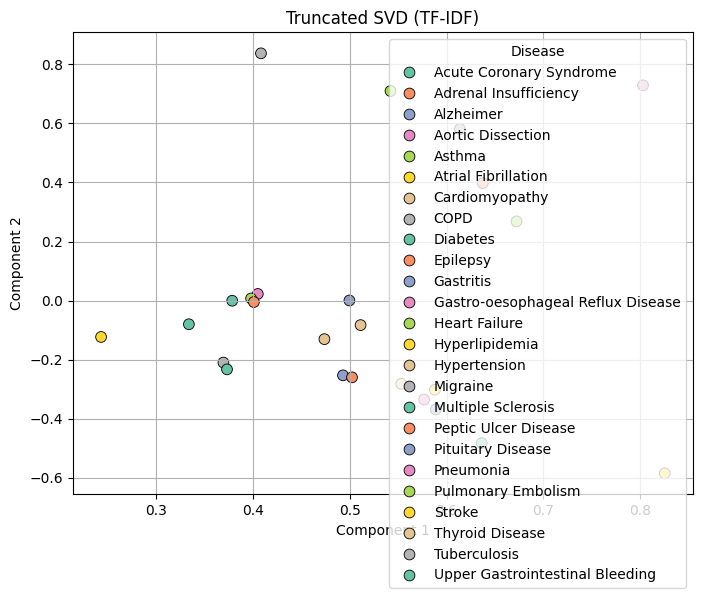

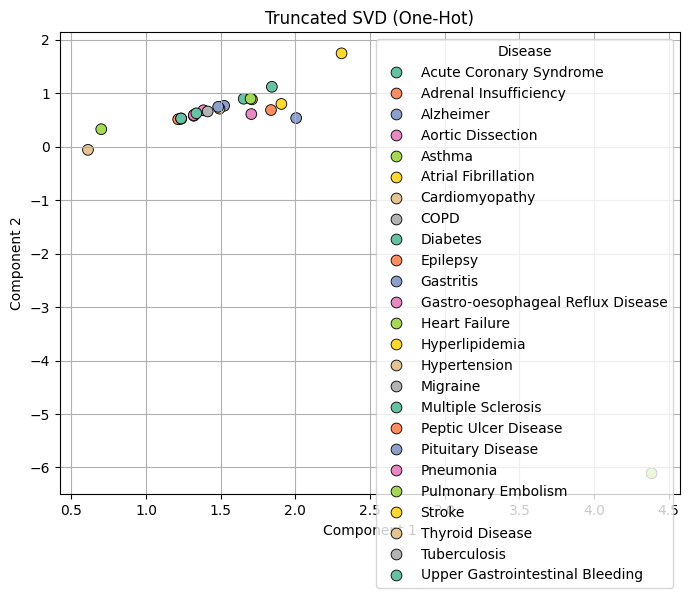

In [22]:
plot_2d(X_svd_tfidf, "Truncated SVD (TF-IDF)", labels)
plot_2d(X_svd_onehot, "Truncated SVD (One-Hot)", labels)


In [23]:
from sklearn.model_selection import cross_val_score, cross_validate, StratifiedKFold
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics.pairwise import cosine_distances
import numpy as np


In [24]:
# Choose target column
y = one_hot_df['Disease'] if 'Disease' in one_hot_df.columns else df['Disease']
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Already prepared earlier:
# X_tfidf_combined (sparse)
# onehot_numeric (dense)
X_tfidf = X_tfidf_combined
X_onehot = onehot_numeric.to_numpy()


In [39]:
from collections import Counter

# Count each class
label_counts = Counter(y_encoded)

# Print the distribution
print("Original label counts:")
for label, count in label_counts.items():
    print(f"Class {label}: {count} samples")

# Show how many are >= 2
valid_labels = [label for label, count in label_counts.items() if count >= 2]
print(f"\nValid labels with ≥ 2 samples: {len(valid_labels)}")


Original label counts:
Class 0: 1 samples
Class 1: 1 samples
Class 2: 1 samples
Class 3: 1 samples
Class 4: 1 samples
Class 5: 1 samples
Class 7: 1 samples
Class 6: 1 samples
Class 8: 1 samples
Class 9: 1 samples
Class 10: 1 samples
Class 11: 1 samples
Class 12: 1 samples
Class 13: 1 samples
Class 14: 1 samples
Class 15: 1 samples
Class 16: 1 samples
Class 17: 1 samples
Class 18: 1 samples
Class 19: 1 samples
Class 20: 1 samples
Class 21: 1 samples
Class 22: 1 samples
Class 23: 1 samples
Class 24: 1 samples

Valid labels with ≥ 2 samples: 0


In [40]:
df.columns



Index(['Disease', 'Risk Factors', 'Symptoms', 'Signs', 'Subtypes',
       'Risk Factors_str', 'Symptoms_str', 'Signs_str'],
      dtype='object')

In [42]:
df['LabelGroup'] = ['Group ' + str(i//5 + 1) for i in range(len(df))]
df['LabelGroup'].value_counts()


,count
LabelGroup,
Group 1,5
Group 2,5
Group 3,5
Group 4,5
Group 5,5


In [43]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(df['LabelGroup'])


In [47]:
from sklearn.preprocessing import LabelEncoder

# Encode new labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(df['LabelGroup'])


In [48]:
X_tfidf = X_tfidf_combined
X_onehot = onehot_numeric.to_numpy()


In [49]:
def evaluate_knn(X, y, metric, k_values=[3, 5, 7], model_name="TF-IDF"):
    results = []
    from collections import Counter
    min_class_count = min(Counter(y).values())
    n_splits = min(3, min_class_count)
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    for k in k_values:
        if metric == "cosine":
            dists = cosine_distances(X)
            knn = KNeighborsClassifier(n_neighbors=k, metric='precomputed')
            scores = cross_validate(knn, dists, y, cv=cv,
                                    scoring=['accuracy', 'precision_weighted', 'recall_weighted', 'f1_weighted'])
        else:
            knn = KNeighborsClassifier(n_neighbors=k, metric=metric)
            scores = cross_validate(knn, X, y, cv=cv,
                                    scoring=['accuracy', 'precision_weighted', 'recall_weighted', 'f1_weighted'])

        results.append({
            'Model': f'KNN ({model_name})',
            'Distance': metric,
            'k': k,
            'Accuracy': np.mean(scores['test_accuracy']),
            'Precision': np.mean(scores['test_precision_weighted']),
            'Recall': np.mean(scores['test_recall_weighted']),
            'F1': np.mean(scores['test_f1_weighted'])
        })

    return results


In [50]:
def evaluate_logistic(X, y, model_name):
    clf = LogisticRegression(max_iter=500)
    from collections import Counter
    min_class_count = min(Counter(y).values())
    n_splits = min(3, min_class_count)
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    scores = cross_validate(clf, X, y, cv=cv,
                            scoring=['accuracy', 'precision_weighted', 'recall_weighted', 'f1_weighted'])

    return {
        'Model': f'LogReg ({model_name})',
        'Distance': 'N/A',
        'k': '-',
        'Accuracy': np.mean(scores['test_accuracy']),
        'Precision': np.mean(scores['test_precision_weighted']),
        'Recall': np.mean(scores['test_recall_weighted']),
        'F1': np.mean(scores['test_f1_weighted'])
    }


In [51]:
# KNN
tfidf_knn_results = []
for dist in ['euclidean', 'manhattan', 'cosine']:
    tfidf_knn_results += evaluate_knn(X_tfidf, y_encoded, dist, model_name="TF-IDF")

onehot_knn_results = []
for dist in ['euclidean', 'manhattan', 'cosine']:
    onehot_knn_results += evaluate_knn(X_onehot, y_encoded, dist, model_name="One-Hot")

# Logistic Regression
logreg_tfidf = evaluate_logistic(X_tfidf.toarray(), y_encoded, model_name="TF-IDF")
logreg_onehot = evaluate_logistic(X_onehot, y_encoded, model_name="One-Hot")


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/m

In [56]:
all_results = tfidf_knn_results + onehot_knn_results + [logreg_tfidf, logreg_onehot]
results_df = pd.DataFrame(all_results)

# Show result table in Colab
print("✅ Model Performance Comparison (TF-IDF vs One-Hot, KNN vs Logistic Regression)")
results_df


✅ Model Performance Comparison (TF-IDF vs One-Hot, KNN vs Logistic Regression)


,Model,Distance,k,Accuracy,Precision,Recall,F1
0,KNN (TF-IDF),euclidean,3,0.162037,0.083719,0.162037,0.099868
1,KNN (TF-IDF),euclidean,5,0.115741,0.089120,0.115741,0.074280
2,KNN (TF-IDF),euclidean,7,0.120370,0.024949,0.120370,0.040146
3,KNN (TF-IDF),manhattan,3,0.162037,0.030157,0.162037,0.050000
4,KNN (TF-IDF),manhattan,5,0.162037,0.033133,0.162037,0.053704
5,KNN (TF-IDF),manhattan,7,0.203704,0.061060,0.203704,0.087963
6,KNN (TF-IDF),cosine,3,0.120370,0.062886,0.120370,0.079630
7,KNN (TF-IDF),cosine,5,0.115741,0.057716,0.115741,0.069444
8,KNN (TF-IDF),cosine,7,0.041667,0.006944,0.041667,0.011905
9,KNN (One-Hot),euclidean,3,0.157407,0.030003,0.157407,0.050084
